## Blackbody Radius Calculation
##### Sophia Kressy

#### This script will take flux measurements from dusty_sn (cr: Sebastian Gomez) and find the predicted blackbody radius for the SNe

##### Import functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

##### Constants/Files

In [2]:
sigma      = 5.66961e-5  # Stefan-Boltzmann constant in erg cm^-2 s^-1 K^-4
dmpc       = 22.8 # User set distance to Target in Mpc
d_cm       = dmpc * 3.086e+24 # convert mpc to cm
paramfile  = 'parameters_SN1983V_2.txt'
comp1_file = 'component_1.txt'
comp2_file = 'component_2.txt'
wavefile   = 'wavelengths.txt'
modelfile  = 'sampled_model.txt'

##### load flux, M_dust, T_dust data from dusty_sn

In [3]:
# load parameter text file from same directory
data = np.loadtxt(paramfile, skiprows=1, usecols=(1,2,3))
log_M_cold = data[0, :]
T_cold     = data[1, :] 
log_M_hot  = data[2, :]
T_hot      = data[3, :]
log_M_tot  = data[4, :]

In [4]:
# grab upper and lower limits of temperature parameter
T_cold_upper     = T_cold[0] + T_cold[1]
T_hot_upper      = T_hot[0] + T_hot[1]

T_cold_lower     = T_cold[0] - T_cold[2]
T_hot_lower      = T_hot[0] - T_hot[2]

print(T_cold)
print(T_cold_upper, T_cold_lower)

print(T_hot)
print(T_hot_upper, T_hot_lower)

[123.04068556   1.99205499   2.01739115]
125.03274055079603 121.02329440320578
[529.12503617  18.02173194  19.78724455]
547.146768113462 509.33779162718236


In [5]:
# load flux data
c1flux    = np.loadtxt(comp1_file, skiprows=1) # Flux in Jy, cold
c2flux    = np.loadtxt(comp2_file, skiprows=1) # Flux in Jy, hot
modelflux = np.loadtxt(modelfile, skiprows=1) # Flux in Jy, hot
wavelength_microns = np.loadtxt(wavefile, skiprows=1) # wavelength in microns


##### Convert flux [Jy] to flux [erg s-1 cm-2 Hz-1]

In [6]:
c1flux_erg = c1flux * 1e-23
c2flux_erg = c2flux * 1e-23
model_erg  = modelflux * 1e-23

##### Convert wavelength to Hz

In [7]:
wavelength_m = wavelength_microns * 1e-6 # convert microns to meters
c = 3e8 # meters s^-1
hz = c / wavelength_m 
Ghz = hz/1e9 # convert Hz to GHz

##### plot flux data (double check it looks like dustysn plot)

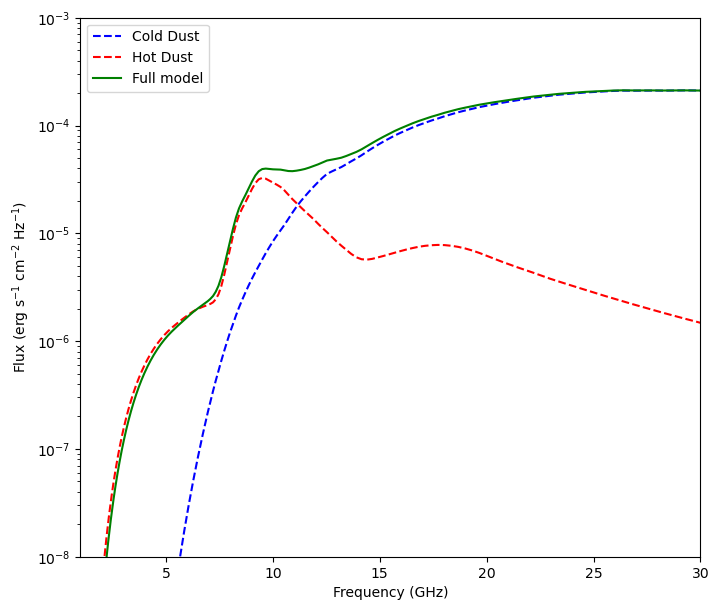

In [8]:
plt.figure(figsize=(8, 7))
plt.plot(wavelength_microns, c1flux, color='blue', linestyle='--', label='Cold Dust')
plt.plot(wavelength_microns, c2flux, color='red', linestyle='--', label='Hot Dust')
plt.plot(wavelength_microns, modelflux, color='green',linestyle='-',label = 'Full model')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Flux (erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$)')
plt.yscale('log')
plt.ylim(10e-9, 10e-4)
plt.xlim(1,30)
plt.legend()

### For EACH dust component (cold + hot)

##### integrate flux to get luminosity

In [9]:
F_cold   = np.abs(np.trapezoid(c1flux_erg, x=hz))  # flux 
F_hot    = np.abs(np.trapezoid(c2flux_erg, x=hz))  # flux
# F_tot  = -1*np.trapezoid(model_erg, x=hz)  # flux

print(F_cold, F_hot)


1.8959941048765396e-14 4.362854354170632e-15


##### define filling factor and multiply by luminosity (for total L)

In [10]:
filling      = 4*np.pi*d_cm**2
L_cold_tot   = filling*F_cold
L_hot_tot    = filling*F_hot
# L_tot  = filling*F_tot

# print("Total Luminosity of Dust: ", L_tot,"[erg s^-1]")
print("Total Luminosity of Carbon Dust: ", L_cold_tot,"[erg s^-1]")
print("Total Luminosity of Silicate Dust: ", L_hot_tot,"[erg s^-1]")

Total Luminosity of Carbon Dust:  1.1795283514182708e+39 [erg s^-1]
Total Luminosity of Silicate Dust:  2.7142016900880644e+38 [erg s^-1]


##### calculate R_BB from L_tot

In [11]:
# Calculate the blackbody radius for the silicate and carbon components
R_cold_bb = np.sqrt(L_cold_tot / (4 * np.pi * sigma * T_cold[0]**4))
R_hot_bb  = np.sqrt(L_hot_tot / (4 * np.pi * sigma * T_hot[0]**4))

# upper limits form T
R_cold_bb_upper = np.sqrt(L_cold_tot / (4 * np.pi * sigma * T_cold_upper**4))
R_hot_bb_upper  = np.sqrt(L_hot_tot / (4 * np.pi * sigma * T_hot_upper**4))

# upper limits form T
R_cold_bb_lower = np.sqrt(L_cold_tot / (4 * np.pi * sigma * T_cold_lower**4))
R_hot_bb_lower  = np.sqrt(L_hot_tot / (4 * np.pi * sigma * T_hot_lower**4))

# R_bb = np.sqrt(L_tot / (4 * np.pi * sigma * T_cold**4))

# print("Blackbody Radius:", R_bb[0],"[cm]") #, "Upper:", R_bb[1], "Lower:", R_bb[2])
print("Blackbody Radius of Cold Dust:", R_cold_bb,"[cm]", "Upper:", R_cold_bb_upper, "Lower:", R_cold_bb_lower) #, "Upper:", R_cold_bb[1], "Lower:", R_cold_bb[2])
print("Blackbody Radius of Hot Dust:", R_hot_bb,"[cm]", "Upper:", R_hot_bb_upper, "Lower:", R_hot_bb_lower) #, "Upper:", R_hot_bb[1], "Lower:", R_hot_bb[2])


Blackbody Radius of Cold Dust: 8.499143905270382e+16 [cm] Upper: 8.23048004526604e+16 Lower: 8.784857590047696e+16
Blackbody Radius of Hot Dust: 2204565014473528.5 [cm] Upper: 2061730315748749.8 Lower: 2379182361497527.5


In [12]:
# convert to ly
# R_cold_bb_ly = R_cold_bb / 1.496e+13 #9.4605e17  # light years #1e5 # km
# R_hot_bb_ly  = R_hot_bb  / 1.496e+13 #9.4605e17  # light years #1e5 # km
# print("In light years:", R_cold_bb_ly[0],"[ly]", "Upper:", R_cold_bb_ly[1], "Lower:", R_cold_bb_ly[2])
# print("In light years:", R_hot_bb_ly[0],"[ly]", "Upper:", R_hot_bb_ly[1], "Lower:", R_hot_bb_ly[2])

### Calculate R_shock, from V_shock, t_shock 
#####       & Compare to R_BB

In [13]:
years_since_explo = 39
s_in_year = 3.154e+7
days_in_year = 365.25
cm_in_km = 100000
km_in_cm = 1e-5

# calculate velocity in cm/s for Hot and Cold components + upper and lower limits
hot_velocity        = R_hot_bb/(years_since_explo*s_in_year) # cm/s
hot_velocity_upper  = R_hot_bb_upper/(years_since_explo*s_in_year) # cm/s
hot_velocity_lower  = R_hot_bb_lower/(years_since_explo*s_in_year) # cm/s

cold_velocity       = R_cold_bb/(years_since_explo*s_in_year) # cm/s
cold_velocity_upper = R_cold_bb_upper/(years_since_explo*s_in_year) # cm/s
cold_velocity_lower = R_cold_bb_lower/(years_since_explo*s_in_year) # cm/s

print(hot_velocity*km_in_cm, hot_velocity_upper*km_in_cm, hot_velocity_lower*km_in_cm,'[km/s]')
print(cold_velocity*km_in_cm,cold_velocity_upper*km_in_cm,cold_velocity_lower*km_in_cm,'[km/s]')

# print('Expected Shock Velocity HOT  = ', R_hot_bb/(years_since_explo*s_in_year)*km_in_cm,'[km/s]')
# print('Expected Shock Velocity COLD = ', R_cold_bb/(years_since_explo*s_in_year)*km_in_cm,'[km/s]')


17.92241853627895 16.761217467023968 19.342002516117326 [km/s]
690.9536043177068 669.1120795136856 714.1812261229288 [km/s]


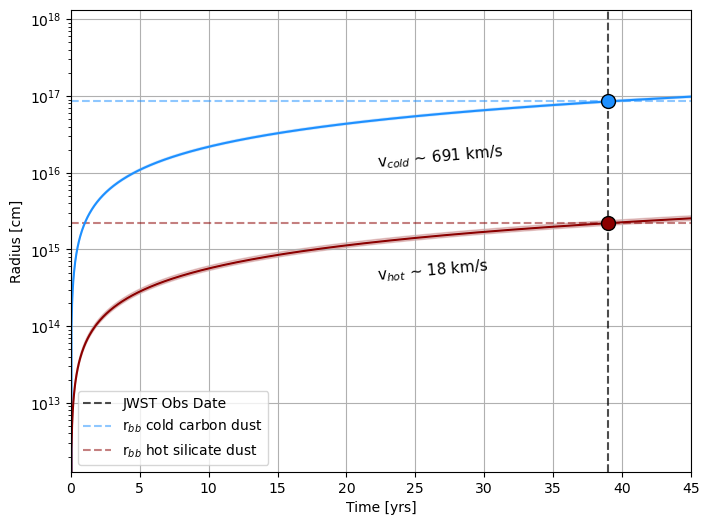

In [15]:
t_shock = np.linspace(0, 45, 1000)*s_in_year
# t_shock_yr = np.linspace(0, 45, 9)
t_shock_yr = np.linspace(0, 45, 10)*s_in_year
t_shock_40 = years_since_explo*s_in_year

# flip upper and lower, since T has inverse relationship - a larger T = smaller radius. 
r_hot       = t_shock*hot_velocity #[s*cm/s = cm]
r_hot_lower = t_shock*hot_velocity_upper
r_hot_upper = t_shock*hot_velocity_lower

r_cold       = t_shock*cold_velocity
r_cold_lower = t_shock*cold_velocity_upper
r_cold_upper = t_shock*cold_velocity_lower

# find radius of 1000 km/s and 5000 km/s shock 
r_1000_array = t_shock*1000*cm_in_km #[s*cm/s = cm]
r_5000_array = t_shock*5000*cm_in_km #[s*cm/s = cm]
r_1000 = t_shock_40*1000*cm_in_km
r_5000 = t_shock_40*5000*cm_in_km

# set up figure
plt.figure(figsize=(8,6))
plt.xlabel('Time [yrs]')
plt.ylabel('Radius [cm]')
plt.yscale('log')

plt.axvline(s_in_year*years_since_explo, linestyle = '--', color = 'black', label='JWST Obs Date', alpha=0.7)
plt.axhline(r_1000, linestyle = '--', color = 'black', alpha = 0)
plt.axhline(r_5000, linestyle = '--', color = 'black', alpha = 0)
plt.axhline(R_cold_bb, linestyle = '--', color = 'dodgerblue', alpha = 0.5, label=r'r$_{bb}$ cold carbon dust')
plt.axhline(R_hot_bb, linestyle = '--', color = 'darkred', alpha = 0.5, label=r'r$_{bb}$ hot silicate dust')

# plot shock radius for cold and hot components
plt.plot(t_shock, r_cold, color = 'dodgerblue') #label = r'v$_{shock}$ for cold, carbon model',
plt.plot(t_shock, r_hot,  color='darkred') #label = r'v$_{shock}$ for hot, silicate model',
plt.xlim((0,s_in_year*42))

# fill between lower and upper limits of hot and cold components
plt.fill_between(t_shock, r_hot_lower, r_hot_upper, color='darkred', alpha=0.2)
plt.fill_between(t_shock, r_cold_lower, r_cold_upper, color='dodgerblue', alpha=0.2)

# overplot radius for 1000km/s and 5000 km/s
plt.plot(t_shock, r_1000_array, color = 'black', alpha=0)
plt.plot(t_shock, r_5000_array, color = 'black', alpha=0)

# plot the one data point we have
plt.plot(s_in_year*years_since_explo, R_cold_bb, marker='o',markerfacecolor='dodgerblue',color='black', markersize=10) #, label=r'Cold R$_{bb}$'
plt.plot(s_in_year*years_since_explo, R_hot_bb, marker='o',markerfacecolor='darkred',color='black', markersize=10) #, label=r'Hot R$_{bb}$'

# labels
plt.text(7e8, 4e14, r'v$_{hot}$ ~ 18 km/s', rotation=5, fontsize = 11) 
plt.text(7e8, 1.2e16, r'v$_{cold}$ ~ 691 km/s', rotation=5, fontsize = 11) 
# plt.text(7e8, 4.3e16, r'v ~ 1000 km/s', rotation=5, fontsize = 11) 
# plt.text(7e8, 2.1e17, r'v ~ 5000 km/s', rotation=5, fontsize = 11) 


plt.xticks(t_shock_yr, ['0', '5', '10','15','20','25','30','35','40','45'])
plt.grid()
plt.legend(loc='lower left')
plt.savefig('expansion_velocity.pdf')


In [29]:
# # v_shock = np.linspace(0.01e3, 6e3, 20)*cm_in_km
# t_shock = np.linspace(1, 42, 42)*s_in_year

# # R_shock_list = []

# plt.figure(figsize=(8,6))
# plt.xlabel('Time [secs]')
# plt.ylabel('Radius [cm]')
# plt.yscale('log')
# # plt.axhline(R_cold_bb[0], linestyle = '--', color = 'blue', label='Carbon')
# # plt.axhline(R_hot_bb[0], linestyle = '--', color = 'red', label = 'Silicate')
# # plt.axvline(39*s_in_year, linestyle = '--', color = 'black', label='date of JWST')

# plt.plot(t_shock, t_shock*hot_velocity, label = 'Silicate', color='darkred')
# plt.plot(t_shock, t_shock*cold_velocity, label = 'Carbon', color = 'dodgerblue')

# # for i in range(len(v_shock)):
# #     R_shock = t_shock*v_shock[i]
# #     plt.plot(t_shock, R_shock)
# #     R_shock_list.append(R_shock)

# plt.xlim((0,1.4e9))
# plt.grid()
# plt.legend()
